# Local Outlier Factor (LOF) for DDoS Detection - Revised

### Key Changes in this Version:
1. **Realistic Contamination Thresholds:** Lowered the `contamination` search grid values. Because the model is trained *only* on normal traffic, high contamination values (like 0.1) force the model to flag 10% of normal traffic as attacks. We now test `0.001` to `0.05`.
2. **FPR-Aware Evaluation:** Replaced generic Precision/Recall with **False Positive Rate (FPR)** and **DDoS Detection Rate**. In network security, keeping the FPR close to 0% is often more critical than a slight boost in detecting anomalies.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score
)

In [19]:
# Load the dataset
df = pd.read_csv("../data/ddos_clean.csv")

# Create binary anomaly label (1 for DDoS, 0 for BENIGN)
df["Anomaly"] = (df[" Label"] != "BENIGN").astype(int)

# Separate features and target
X = df.drop([" Label", "Anomaly"], axis=1)
y_true = df["Anomaly"]

print("Dataset shape:", df.shape)
print(y_true.value_counts())

Dataset shape: (223082, 44)
Anomaly
1    128014
0     95068
Name: count, dtype: int64


In [20]:
# Separate BENIGN and DDoS samples
X_benign = X[y_true == 0]
X_ddos = X[y_true == 1]

# Split BENIGN data: 70% for training, 30% for testing
X_benign_train, X_benign_test = train_test_split(
    X_benign, test_size=0.3, random_state=42
)

print("BENIGN training samples:", X_benign_train.shape)
print("BENIGN test samples:", X_benign_test.shape)
print("DDoS test samples :", X_ddos.shape)

BENIGN training samples: (66547, 42)
BENIGN test samples: (28521, 42)
DDoS test samples : (128014, 42)


In [21]:
# Fit scaler ONLY on BENIGN training data (prevents data leakage)
scaler = StandardScaler()
scaler.fit(X_benign_train)

# Transform all sets using the scaler fitted on training data only
X_train_scaled = scaler.transform(X_benign_train)
X_benign_test_scaled = scaler.transform(X_benign_test)
X_ddos_test_scaled = scaler.transform(X_ddos)

X_test = np.vstack([X_benign_test_scaled, X_ddos_test_scaled])
y_test = np.concatenate([
    np.zeros(len(X_benign_test_scaled)),
    np.ones(len(X_ddos_test_scaled))
]).astype(int)

print("Final training set (BENIGN only):", X_train_scaled.shape)
print("Final test set:", X_test.shape)

Final training set (BENIGN only): (66547, 42)
Final test set: (156535, 42)


In [22]:
def evaluate_lof(n_neighbors, contamination, X_train, X_test, y_test):
    model = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        novelty=True,
        contamination=contamination
    )
    model.fit(X_train)

    y_pred = (model.predict(X_test) == -1).astype(int)

    # Extract confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # REVISION 3: Calculate security-focused metrics
    fpr = fp / (fp + tn)                  # False Positive Rate (Alarm Fatigue)
    benign_acc = tn / (tn + fp)           # Specificity
    ddos_detection_rate = tp / (tp + fn)  # Sensitivity / Recall for DDoS
    f1 = f1_score(y_test, y_pred)

    return {
        "n_neighbors": n_neighbors,
        "contamination": contamination,
        "FPR": fpr,
        "Benign_Acc": benign_acc,
        "DDoS_Detection_Rate": ddos_detection_rate,
        "F1": f1
    }

In [23]:
# REVISION 2: Tune with realistic, low contamination rates 
# Since training data is 100% normal, expected outliers are near 0%.
neighbors_list = [10, 20, 30, 50, 75, 100]
contamination_list = [0.01, 0.05, 0.10, 0.20, 0.30]

results = []

for n in neighbors_list:
    for c in contamination_list:
        print(f"Testing n_neighbors={n}, contamination={c}...")
        res = evaluate_lof(n, c, X_train_scaled, X_test, y_test)
        results.append(res)

Testing n_neighbors=10, contamination=0.01...


Testing n_neighbors=10, contamination=0.05...
Testing n_neighbors=10, contamination=0.1...
Testing n_neighbors=10, contamination=0.2...
Testing n_neighbors=10, contamination=0.3...
Testing n_neighbors=20, contamination=0.01...
Testing n_neighbors=20, contamination=0.05...
Testing n_neighbors=20, contamination=0.1...
Testing n_neighbors=20, contamination=0.2...
Testing n_neighbors=20, contamination=0.3...
Testing n_neighbors=30, contamination=0.01...
Testing n_neighbors=30, contamination=0.05...
Testing n_neighbors=30, contamination=0.1...
Testing n_neighbors=30, contamination=0.2...
Testing n_neighbors=30, contamination=0.3...
Testing n_neighbors=50, contamination=0.01...
Testing n_neighbors=50, contamination=0.05...
Testing n_neighbors=50, contamination=0.1...
Testing n_neighbors=50, contamination=0.2...
Testing n_neighbors=50, contamination=0.3...
Testing n_neighbors=75, contamination=0.01...
Testing n_neighbors=75, contamination=0.05...
Testing n_neighbors=75, contamination=0.1...
T

In [28]:
summary = pd.DataFrame(results)
summary["FPR"] = (summary["FPR"] * 100).round(2).astype(str) + "%"
summary["Benign_Acc"] = summary["Benign_Acc"].round(4)
summary["DDoS_Detection_Rate"] = summary["DDoS_Detection_Rate"].round(4)
summary["F1"] = summary["F1"].round(4)
# Display results, prioritizing models with the highest F1 but keeping an eye on FPR
print("Parameter Grid Results (Sorted by F1):")
print(summary.sort_values(by="F1", ascending=False).reset_index(drop=True))

Parameter Grid Results (Sorted by F1):
    n_neighbors  contamination     FPR  Benign_Acc  DDoS_Detection_Rate  \
0            20           0.10   9.86%      0.9014               0.9990   
1            20           0.20  20.37%      0.7963               0.9996   
2            10           0.20  20.77%      0.7923               0.9993   
3            50           0.20  20.21%      0.7979               0.9978   
4           100           0.20  19.59%      0.8041               0.9832   
5            75           0.30   30.1%      0.6990               0.9996   
6           100           0.30  30.18%      0.6982               0.9997   
7            50           0.30  30.63%      0.6937               0.9999   
8            30           0.30  30.71%      0.6929               0.9995   
9            20           0.30  30.83%      0.6917               0.9997   
10           10           0.30  31.31%      0.6869               0.9995   
11           30           0.20  20.29%      0.7971           


Training final LOF model with n_neighbors=20, contamination=0.1
[[ 25708   2813]
 [   132 127882]]

Final Classification Report :
              precision    recall  f1-score   support

  BENIGN (0)       0.99      0.90      0.95     28521
    DDoS (1)       0.98      1.00      0.99    128014

    accuracy                           0.98    156535
   macro avg       0.99      0.95      0.97    156535
weighted avg       0.98      0.98      0.98    156535



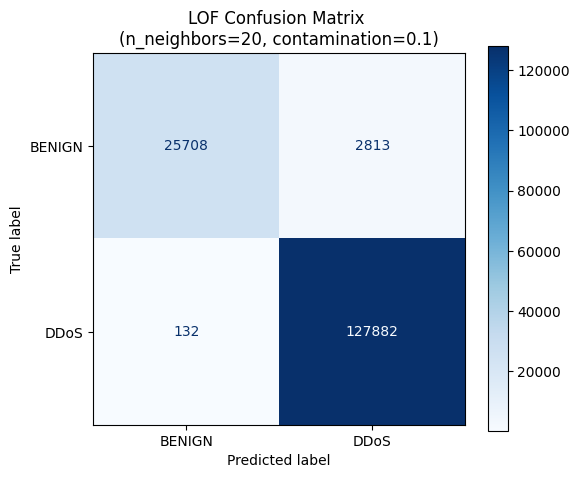

In [32]:
# Select the best model balancing high Detection Rate with a very low FPR.
# You can adjust the iloc[0] to pick a model with specifically lower FPR if desired.
best_params = summary.sort_values(by="F1", ascending=False).iloc[0]
best_n = int(best_params["n_neighbors"])
best_c = best_params["contamination"]

print(f"\nTraining final LOF model with n_neighbors={best_n}, contamination={best_c}")

best_lof = LocalOutlierFactor(n_neighbors=best_n, novelty=True, contamination=best_c)
best_lof.fit(X_train_scaled)
y_pred = (best_lof.predict(X_test) == -1).astype(int)

print(confusion_matrix(y_test, y_pred))
print("\nFinal Classification Report :")
print(classification_report(y_test, y_pred, target_names=["BENIGN (0)", "DDoS (1)"]))


fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["BENIGN", "DDoS"],
    cmap="Blues", values_format='d', ax=ax
)
plt.title(f"LOF Confusion Matrix \n(n_neighbors={best_n}, contamination={best_c})")
plt.show()

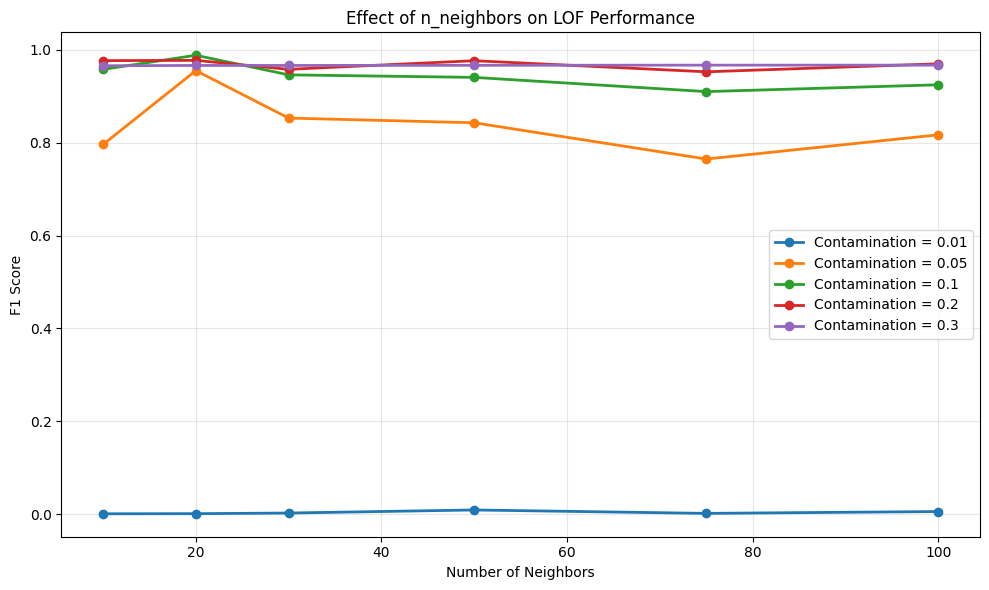

In [ ]:
summary = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10,6))

for c in sorted(summary["contamination"].unique()):
    temp = summary[summary["contamination"] == c]

    ax.plot(
        temp["n_neighbors"],
        temp["F1"],
        marker='o',
        linewidth=2,
        label=f'Contamination = {c}'
    )

ax.set_xlabel("Number of Neighbors")
ax.set_ylabel("F1 Score")
ax.set_title("Effect of n_neighbors on LOF Performance")

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

plt.savefig(
    "../figures/lof_neighbors_vs_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

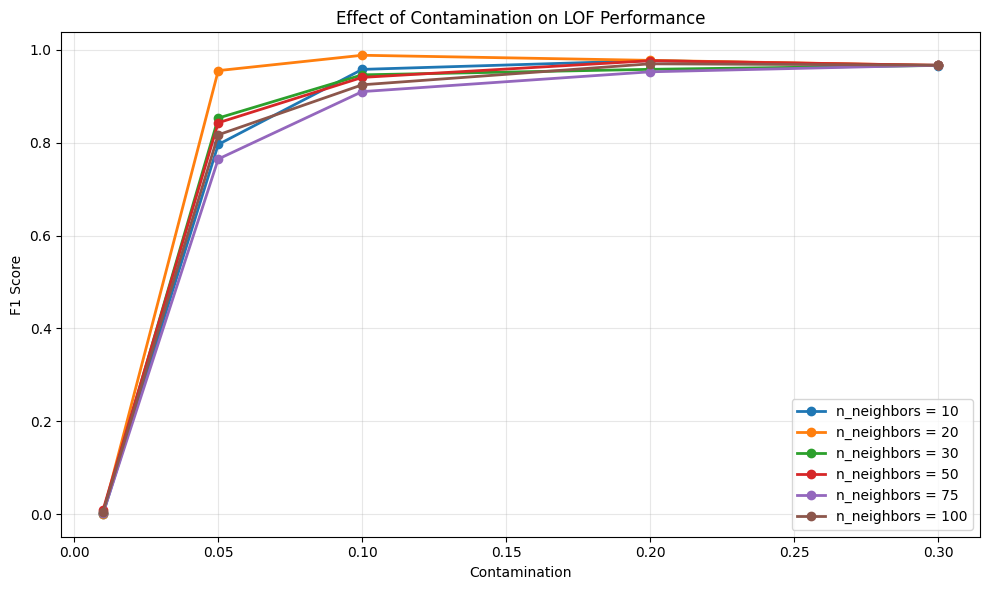

In [35]:
fig, ax = plt.subplots(figsize=(10,6))

for n in sorted(summary["n_neighbors"].unique()):
    temp = summary[summary["n_neighbors"] == n]

    ax.plot(
        temp["contamination"],
        temp["F1"],
        marker='o',
        linewidth=2,
        label=f'n_neighbors = {n}'
    )

ax.set_xlabel("Contamination")
ax.set_ylabel("F1 Score")
ax.set_title("Effect of Contamination on LOF Performance")

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

plt.savefig(
    "../figures/lof_contamination_vs_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

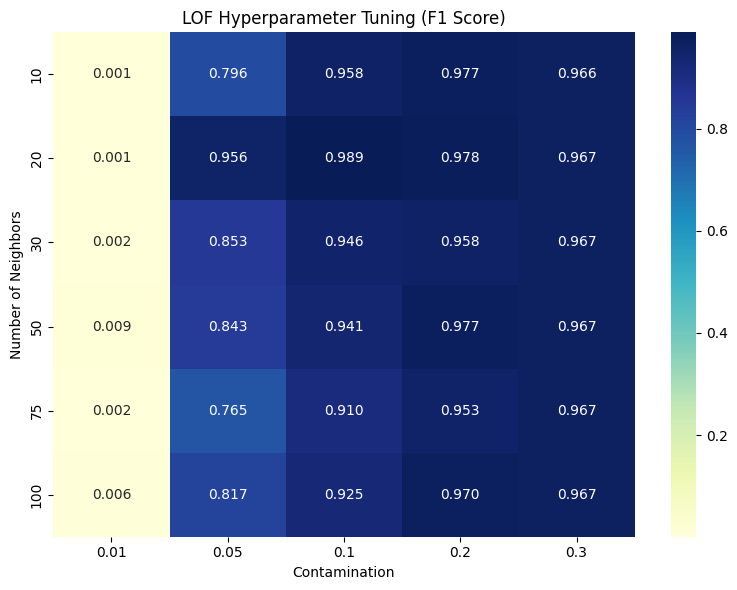

In [36]:
import seaborn as sns

pivot = summary.pivot(
    index="n_neighbors",
    columns="contamination",
    values="F1"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu"
)

plt.title("LOF Hyperparameter Tuning (F1 Score)")
plt.xlabel("Contamination")
plt.ylabel("Number of Neighbors")

plt.tight_layout()

plt.savefig(
    "../figures/lof_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()